In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
import numpy as np
from ultralytics import YOLO
from src.utils import apply_smart_aug
from src.model_utils import export_teeth_in_quad_using_enum_model,analyze_full_teeth_predictions,compare_best_vs_last,get_review_candidates,dedupe_gt_label_files


In [2]:
with open('../configs/stage2.yaml','r') as f:

    stage2_config = yaml.safe_load(f)


with open('../configs/stage2_continued.yaml','r') as f:

    stage2_cont_config = yaml.safe_load(f)


with open('../configs/stage3.yaml','r') as f:

    stage3_config = yaml.safe_load(f)


with open(stage2_config['model_args']['data'],'r') as f:

    enum_data_yaml = yaml.safe_load(f)


with open(stage2_cont_config['model_args']['data'],'r') as f:

    dis_data_yaml = yaml.safe_load(f)


with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [3]:
dedupe_gt_label_files(dis_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),dry_run=False)

100%|██████████| 1439/1439 [00:00<00:00, 6509.20it/s]

Files with duplicates: 0 out of 1439


""


In [4]:
dedupe_gt_label_files(dis_data_yaml['DISEASE_ONLY']['val'].replace('images','labels'),dry_run=False)

100%|██████████| 181/181 [00:00<00:00, 7561.22it/s]

Files with duplicates: 0 out of 181


""


In [5]:
dedupe_gt_label_files(dis_data_yaml['DISEASE_ONLY']['test'].replace('images','labels'),dry_run=False)

100%|██████████| 175/175 [00:00<00:00, 7115.61it/s]

Files with duplicates: 0 out of 175


""


In [6]:
s2_test_results = compare_best_vs_last(enum_data_yaml,trained_models_config,
                                'enum',
                                'test',
                                main_result_path='../Runs/Stage 2/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 248/248 [00:11<00:00, 22.41it/s]



Top 10 problematic images (most warnings):
  duplicates: 3, low_confidence: 1, missing: 132, leaks: 0, background: 0, successful: 8, avg_conf: 0.8237
enumeration_detection_model - last


100%|██████████| 248/248 [00:09<00:00, 26.33it/s]


Top 10 problematic images (most warnings):
  duplicates: 3, low_confidence: 0, missing: 132, leaks: 0, background: 0, successful: 6, avg_conf: 0.8833

Test set summary
enumeration_detection_model_best: total_errors=4, avg_confidence=0.8237
enumeration_detection_model_last: total_errors=3, avg_confidence=0.8833

Lowest total errors on test set: enumeration_detection_model_last with 3 errors


In [7]:
s3_train_results = compare_best_vs_last(dis_data_yaml['DISEASE_ONLY'],trained_models_config,
                                'enum',
                                'train',
                                main_result_path='../Runs/Stage 3/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 1439/1439 [00:54<00:00, 26.19it/s]



Top 10 problematic images (most warnings):
  duplicates: 240, low_confidence: 126, missing: 834, leaks: 166, background: 1, successful: 7613, avg_conf: 0.9205
enumeration_detection_model - last


100%|██████████| 1439/1439 [00:54<00:00, 26.45it/s]


Top 10 problematic images (most warnings):
  duplicates: 176, low_confidence: 103, missing: 831, leaks: 161, background: 1, successful: 7617, avg_conf: 0.9372

Test set summary
enumeration_detection_model_best: total_errors=533, avg_confidence=0.9205
enumeration_detection_model_last: total_errors=441, avg_confidence=0.9372

Lowest total errors on test set: enumeration_detection_model_last with 441 errors


In [8]:
s3_valid_results = compare_best_vs_last(dis_data_yaml['DISEASE_ONLY'],trained_models_config,
                                'enum',
                                'valid',
                                main_result_path='../Runs/Stage 3/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 181/181 [00:07<00:00, 25.44it/s]



Top 10 problematic images (most warnings):
  duplicates: 23, low_confidence: 16, missing: 104, leaks: 17, background: 0, successful: 963, avg_conf: 0.9171
enumeration_detection_model - last


100%|██████████| 181/181 [00:06<00:00, 25.89it/s]


Top 10 problematic images (most warnings):
  duplicates: 27, low_confidence: 16, missing: 103, leaks: 15, background: 0, successful: 965, avg_conf: 0.9309

Test set summary
enumeration_detection_model_best: total_errors=56, avg_confidence=0.9171
enumeration_detection_model_last: total_errors=58, avg_confidence=0.9309

Lowest total errors on test set: enumeration_detection_model_best with 56 errors


In [9]:
s3_test_results = compare_best_vs_last(dis_data_yaml['DISEASE_ONLY'],trained_models_config,
                                'enum',
                                'test',
                                main_result_path='../Runs/Stage 3/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 175/175 [00:07<00:00, 24.46it/s]



Top 10 problematic images (most warnings):
  duplicates: 23, low_confidence: 12, missing: 93, leaks: 25, background: 0, successful: 953, avg_conf: 0.9252
enumeration_detection_model - last


100%|██████████| 175/175 [00:07<00:00, 24.71it/s]



Top 10 problematic images (most warnings):
  duplicates: 18, low_confidence: 11, missing: 87, leaks: 22, background: 0, successful: 960, avg_conf: 0.9410

Test set summary
enumeration_detection_model_best: total_errors=60, avg_confidence=0.9252
enumeration_detection_model_last: total_errors=51, avg_confidence=0.9410

Lowest total errors on test set: enumeration_detection_model_last with 51 errors


Total images processed: 248
Total events logged: 2155



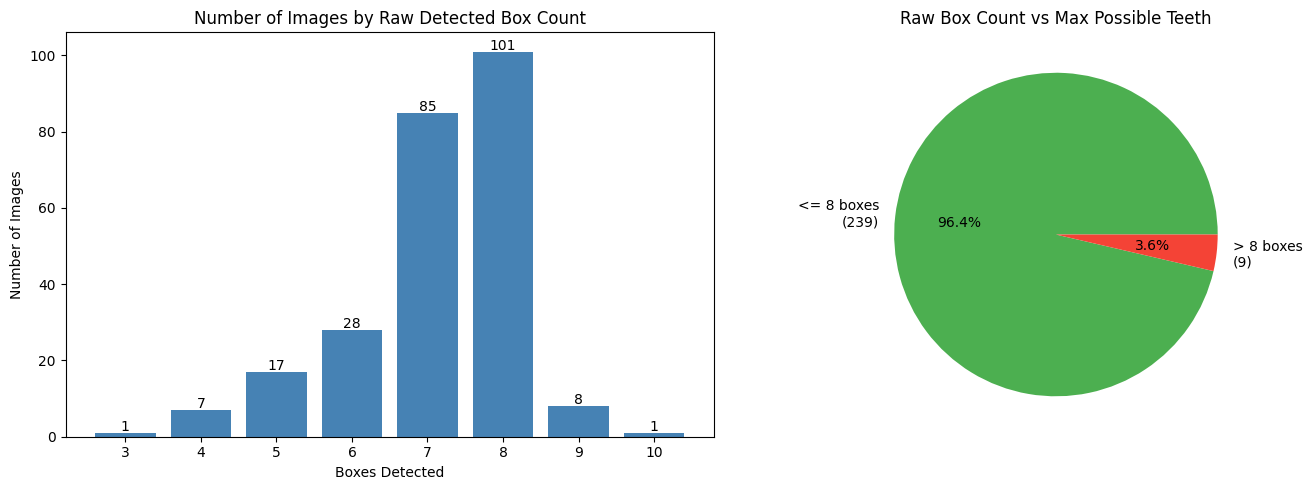

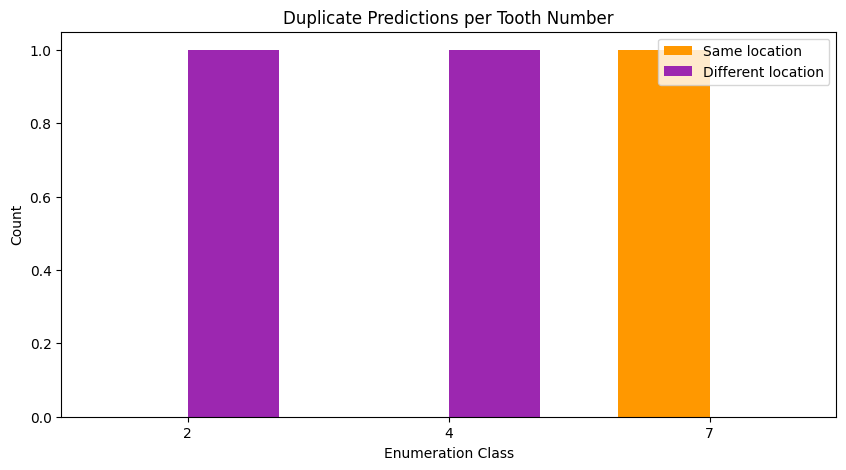

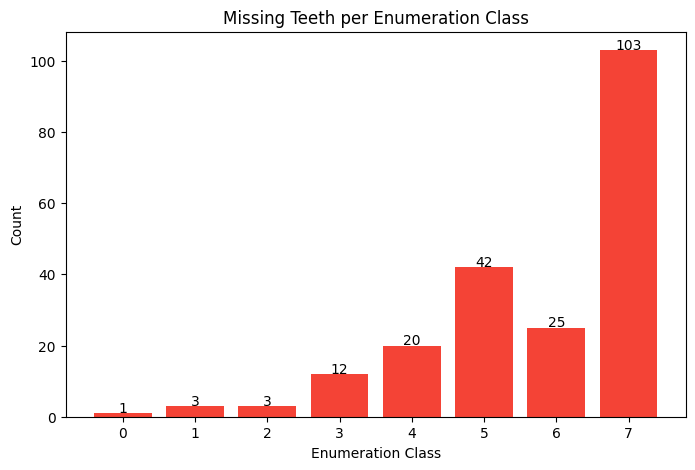

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 1727
No possible cross-quadrant leaks flagged.
No possible background predictions flagged.
No low confidence predictions found.

Average HIGH confidence (>= 0.6): 0.931
Average LOW confidence  (< 0.6): 0.437
Confidence Gap: 0.493  (std=0.110, n_low=60 -> large, model is inconsistent)


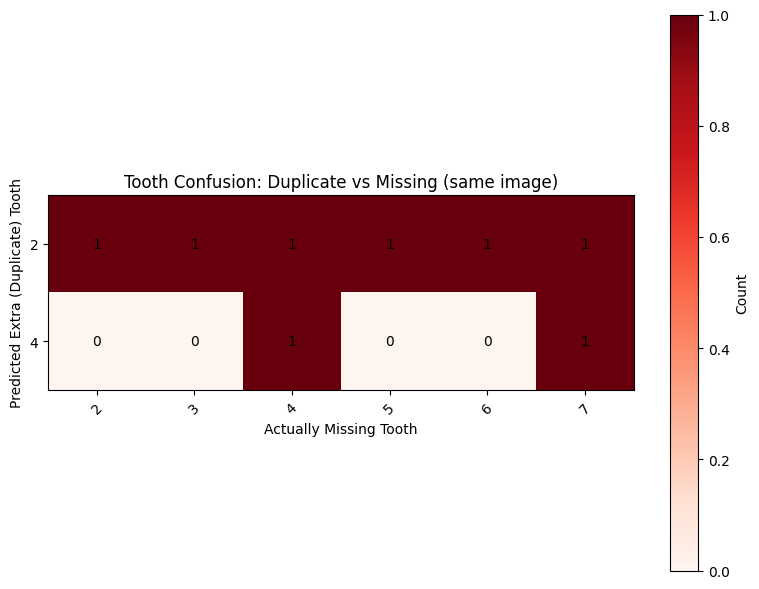


Top 10 problematic images (most warnings):
File_Name
train_386_UpperRight.png    2
train_538_LowerRight.png    2
train_565_UpperRight.png    2
train_109_LowerLeft.png     1
train_109_LowerRight.png    1
train_109_UpperLeft.png     1
train_109_UpperRight.png    1
train_119_LowerLeft.png     1
train_119_LowerRight.png    1
train_119_UpperLeft.png     1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 2/Enumeration Model Crop Analysis\test
File Name: train_332_LowerRight.png
Reason: tooth 4 conflicts with anchors (expected class between 5 and 6)
File Name: train_342_UpperRight.png
Reason: tooth 7 box is 1.7x the median width, may span two teeth
File Name: train_384_UpperRight.png
Reason: tooth 7 box is 1.6x the median width, may span two teeth


In [11]:
s2_test_log_df = s2_test_results['test_set_results']['enumeration_detection_model_last']['log_df']
analyze_full_teeth_predictions(s2_test_log_df,export_dir='../Runs/Stage 2/Enumeration Model Crop Analysis',split_name='test')
get_review_candidates(s2_test_log_df)

Total images processed: 1439
Total events logged: 14040



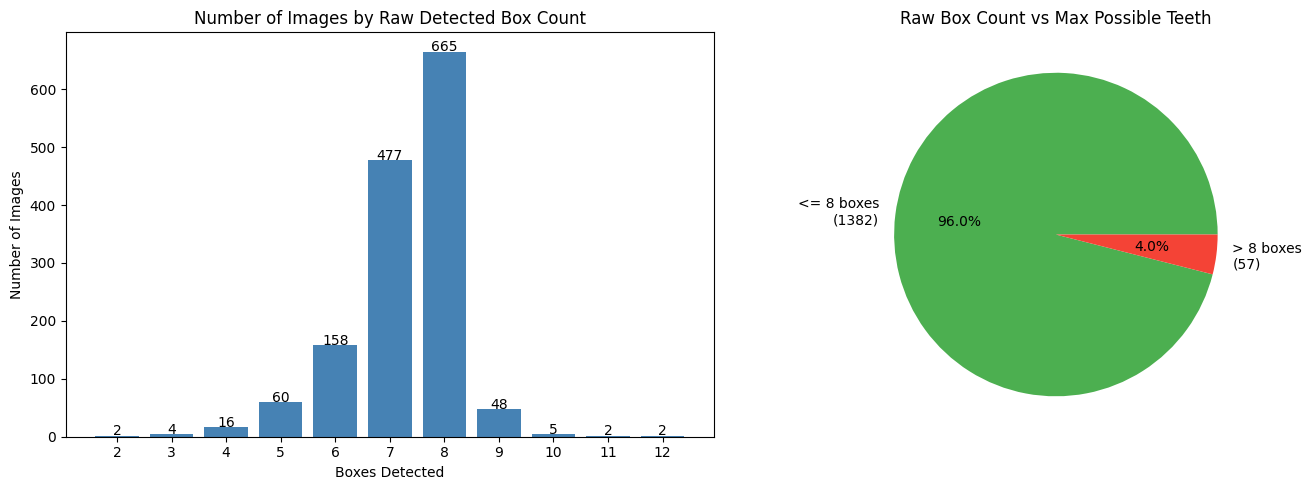

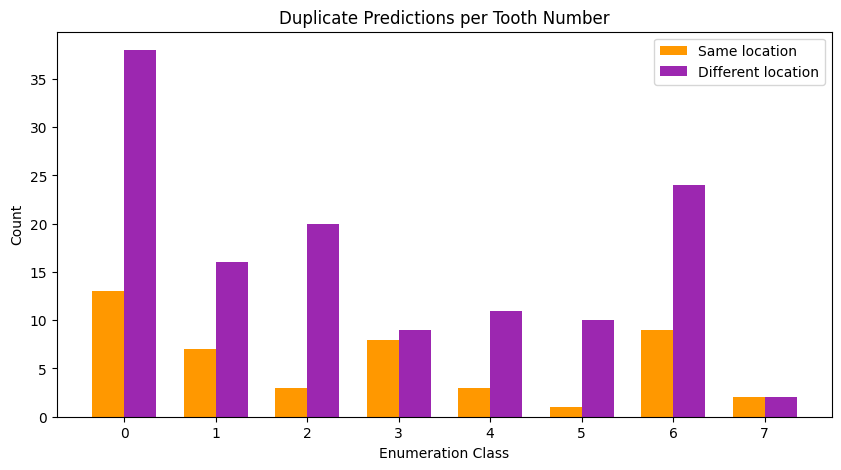

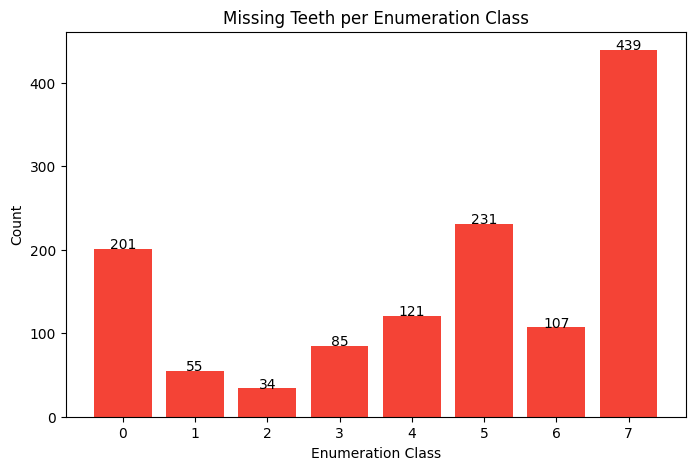

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 2466


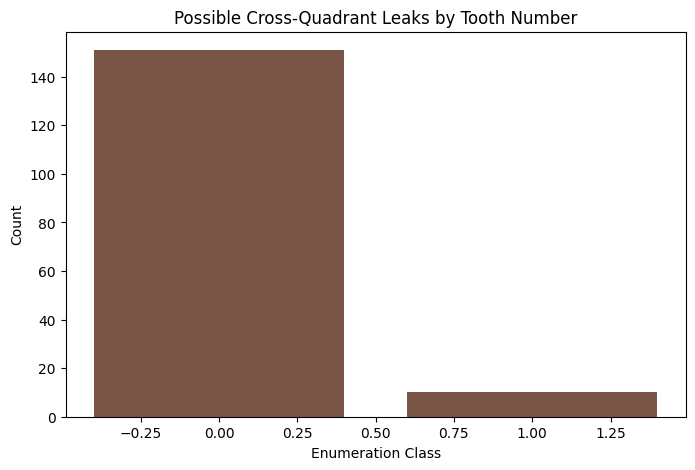

Total possible cross-quadrant leaks flagged: 161 (heuristic, worth a manual look)


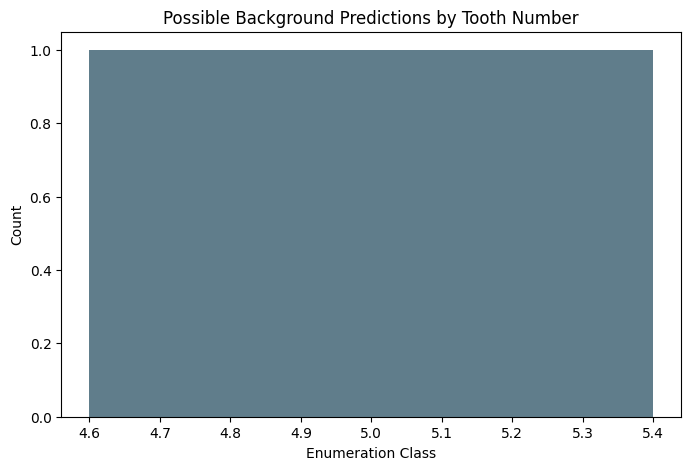

Total possible background predictions flagged: 1 (heuristic, worth a manual look)


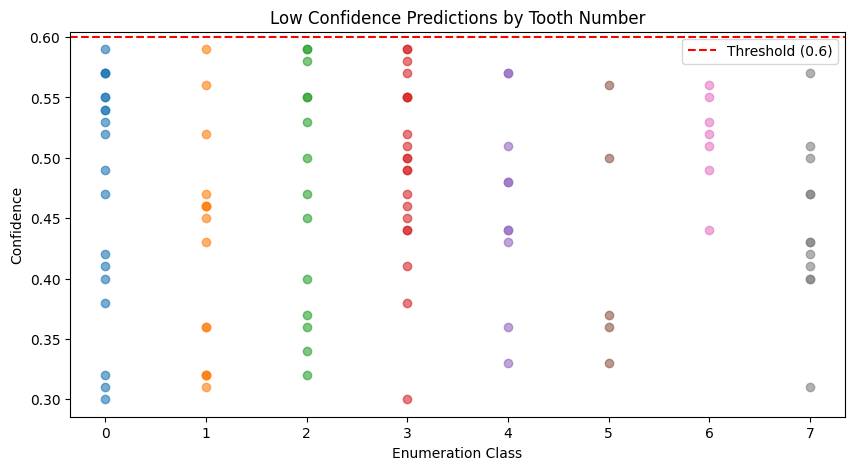


Total low confidence warnings: 103
            count      mean   min
enum_class                       
0              19  0.475263  0.30
1              15  0.426000  0.31
2              14  0.471429  0.32
3              21  0.492381  0.30
4              10  0.461000  0.33
5               5  0.424000  0.33
6               7  0.514286  0.44
7              12  0.443333  0.31

Average HIGH confidence (>= 0.6): 0.943
Average LOW confidence  (< 0.6): 0.457
Confidence Gap: 0.486  (std=0.105, n_low=402 -> large, model is inconsistent)


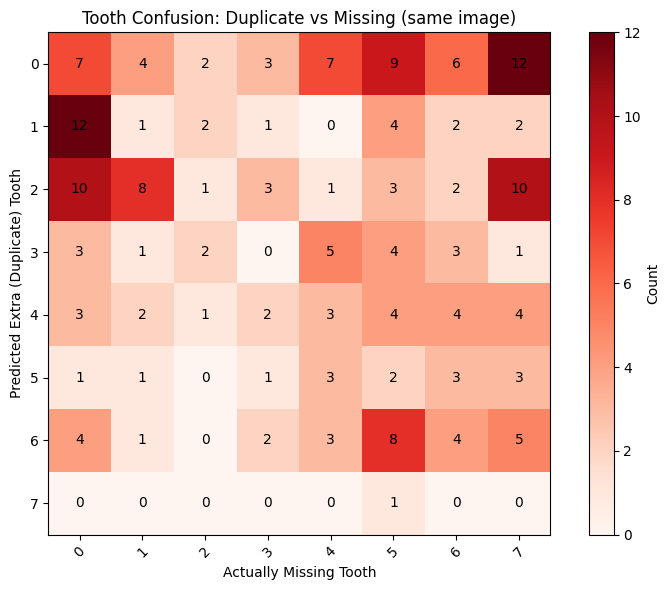


Top 10 problematic images (most warnings):
File_Name
train_370_LowerRight.png    6
train_664_LowerRight.png    6
train_251_LowerLeft.png     5
train_616_LowerLeft.png     5
train_143_UpperRight.png    4
train_172_LowerRight.png    4
train_230_LowerRight.png    4
train_254_UpperLeft.png     4
train_420_LowerLeft.png     4
train_481_LowerRight.png    4
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Enumeration Model Crop Analysis\train


In [12]:
s3_train_log_df = s3_train_results['test_set_results']['enumeration_detection_model_last']['log_df']
s3_train_worst_df = s3_train_results['test_set_results']['enumeration_detection_model_last']['worst_images_df']

analyze_full_teeth_predictions(s3_train_log_df,export_dir='../Runs/Stage 3/Enumeration Model Crop Analysis',split_name='train')
s3_train_review = get_review_candidates(s3_train_log_df,True)

Total images processed: 181
Total events logged: 1758



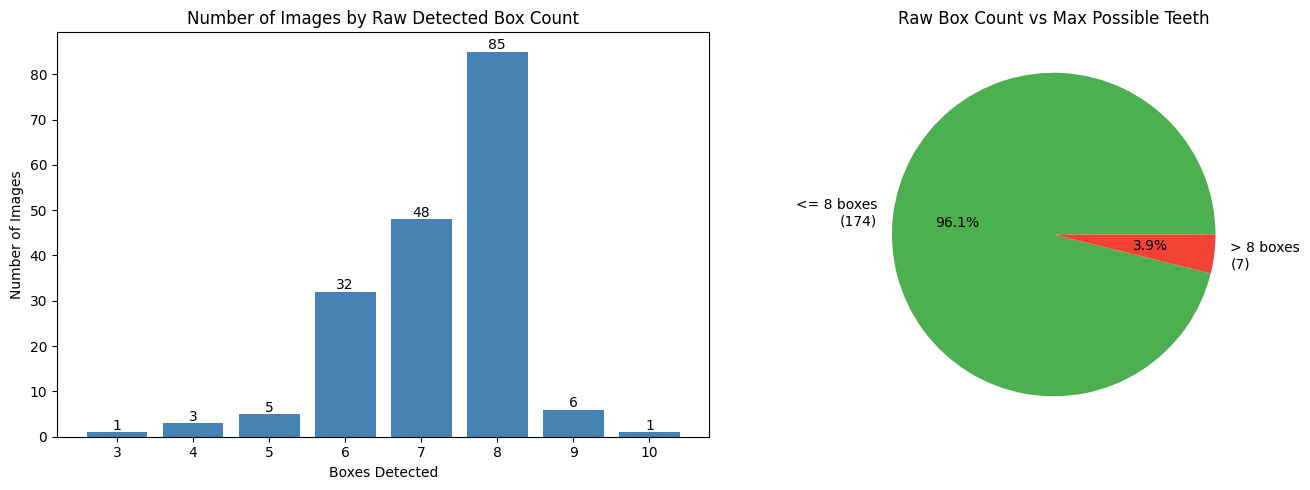

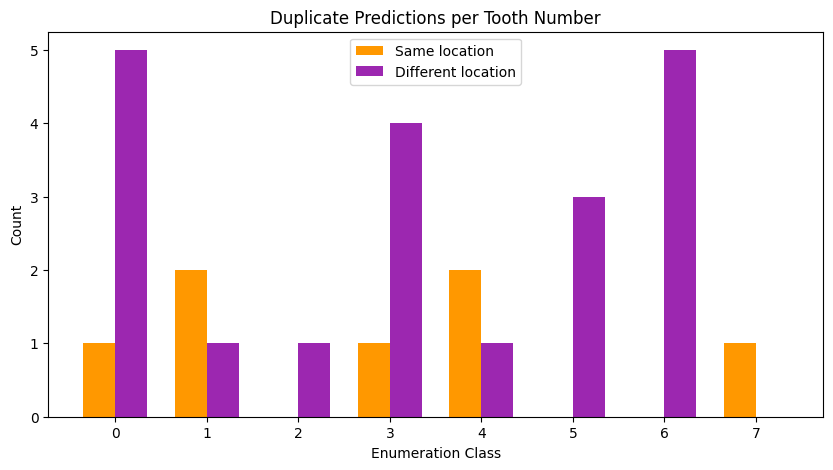

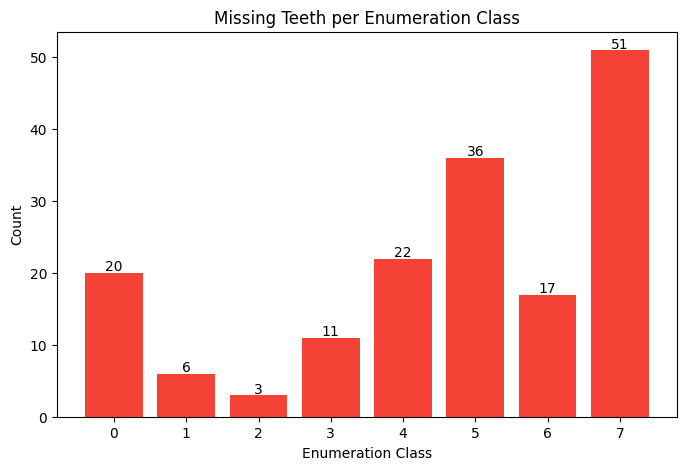

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 292


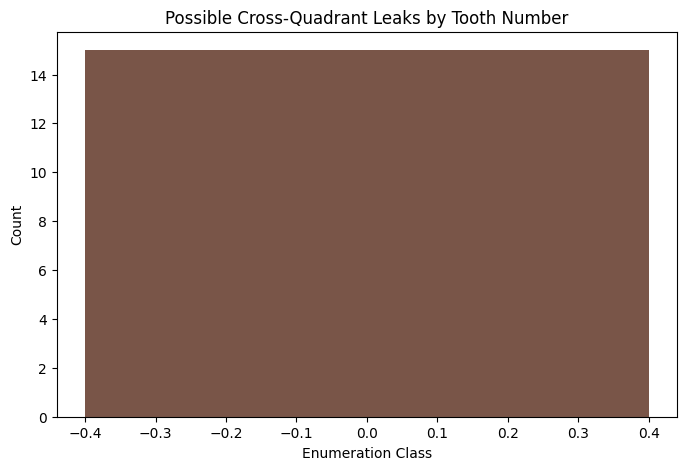

Total possible cross-quadrant leaks flagged: 15 (heuristic, worth a manual look)
No possible background predictions flagged.


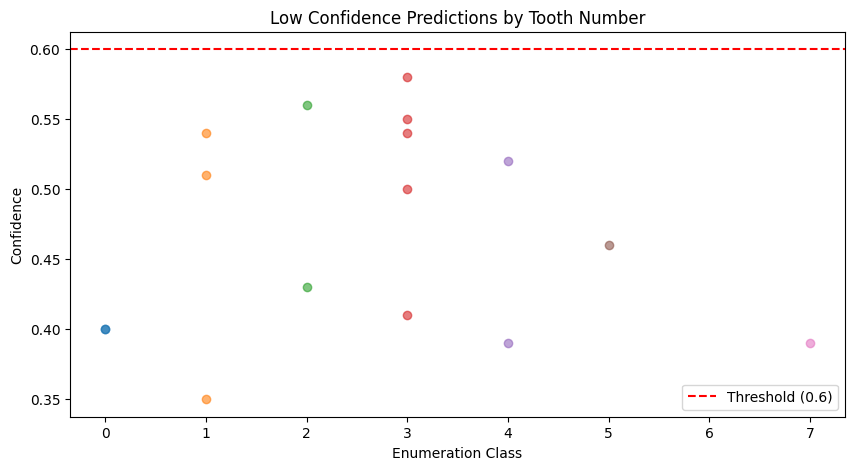


Total low confidence warnings: 16
            count      mean   min
enum_class                       
0               2  0.400000  0.40
1               3  0.466667  0.35
2               2  0.495000  0.43
3               5  0.516000  0.41
4               2  0.455000  0.39
5               1  0.460000  0.46
7               1  0.390000  0.39

Average HIGH confidence (>= 0.6): 0.938
Average LOW confidence  (< 0.6): 0.455
Confidence Gap: 0.483  (std=0.113, n_low=59 -> large, model is inconsistent)


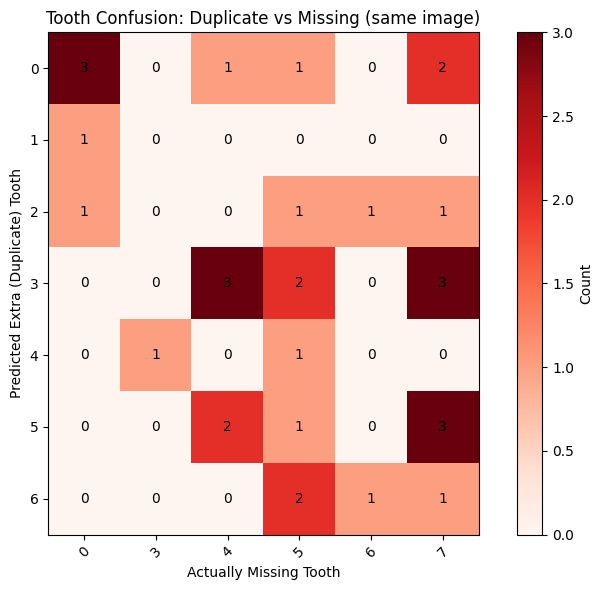


Top 10 problematic images (most warnings):
File_Name
train_40_UpperLeft.png      5
train_522_UpperRight.png    5
train_30_LowerRight.png     4
train_474_LowerLeft.png     3
train_514_UpperLeft.png     3
train_691_LowerLeft.png     3
train_101_LowerLeft.png     2
train_11_LowerRight.png     2
train_148_LowerLeft.png     2
train_187_LowerRight.png    2
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Enumeration Model Crop Analysis\valid
File Name: train_101_LowerRight.png
Reason: tooth 5 box is 2.4x the median width, may span two teeth | tooth 6 box is 3.0x the median width, may span two teeth
File Name: train_148_LowerLeft.png
Reason: tooth 6 box is 1.7x the median width, may span two teeth
File Name: train_148_LowerRight.png
Reason: tooth 5 box is 2.1x the median width, may span two teeth
File Name: train_148_UpperLeft.png
Reason: tooth 6 box is 1.6x the median width, may span two teeth
File Name: train_156_LowerRight.png
Reason: tooth 6 box is 1.9x the median

In [13]:
s3_valid_log_df = s3_valid_results['test_set_results']['enumeration_detection_model_last']['log_df']
s3_valid_worst_df = s3_valid_results['test_set_results']['enumeration_detection_model_last']['worst_images_df']
analyze_full_teeth_predictions(s3_valid_log_df,export_dir='../Runs/Stage 3/Enumeration Model Crop Analysis',split_name='valid')
get_review_candidates(s3_valid_log_df)

Total images processed: 175
Total events logged: 1734



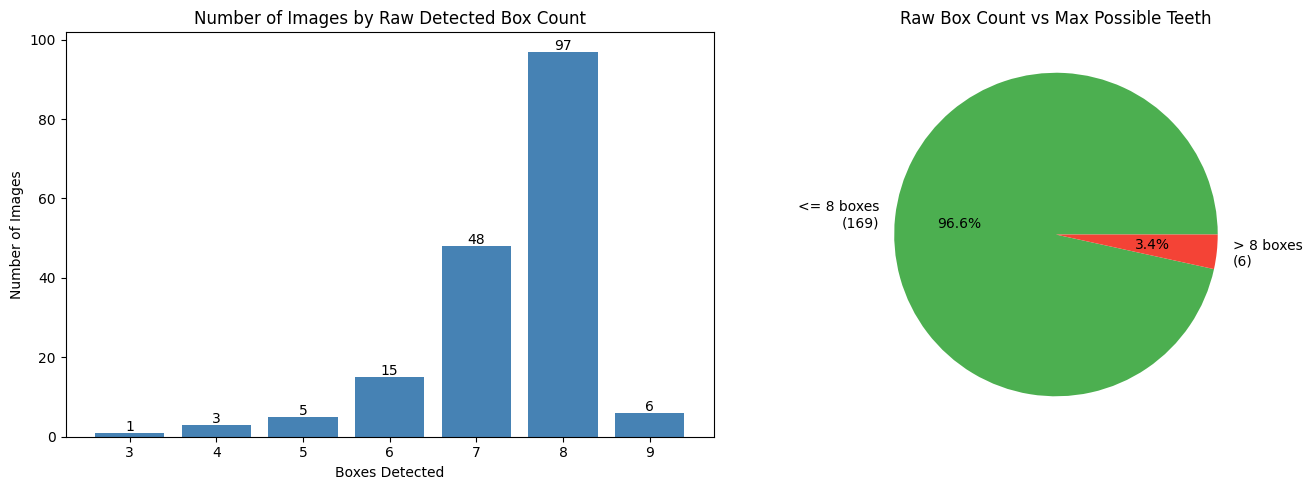

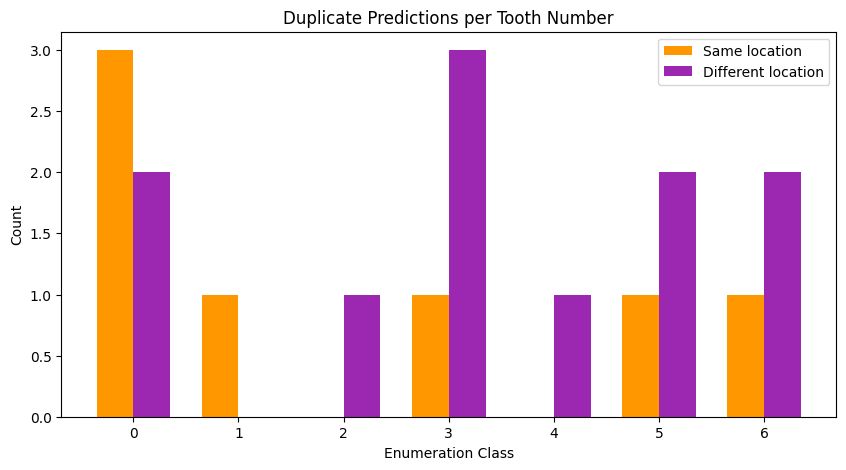

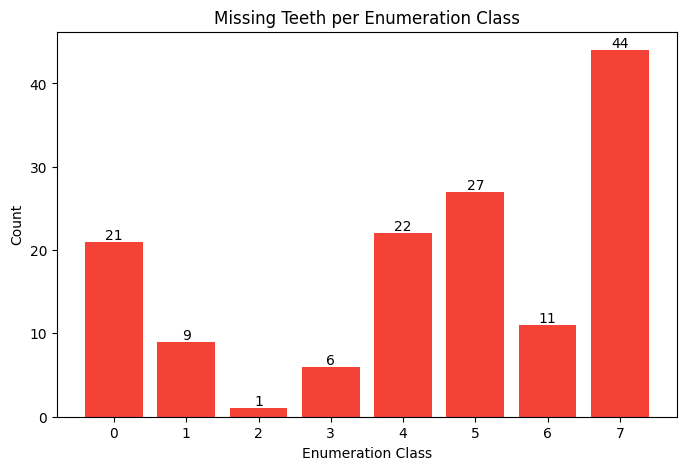

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 291


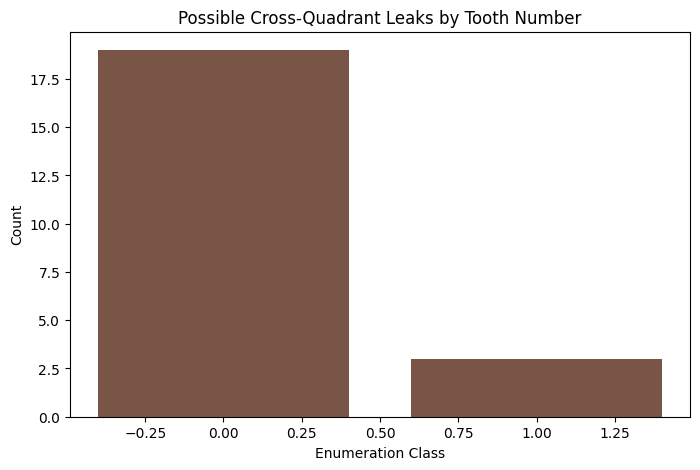

Total possible cross-quadrant leaks flagged: 22 (heuristic, worth a manual look)
No possible background predictions flagged.


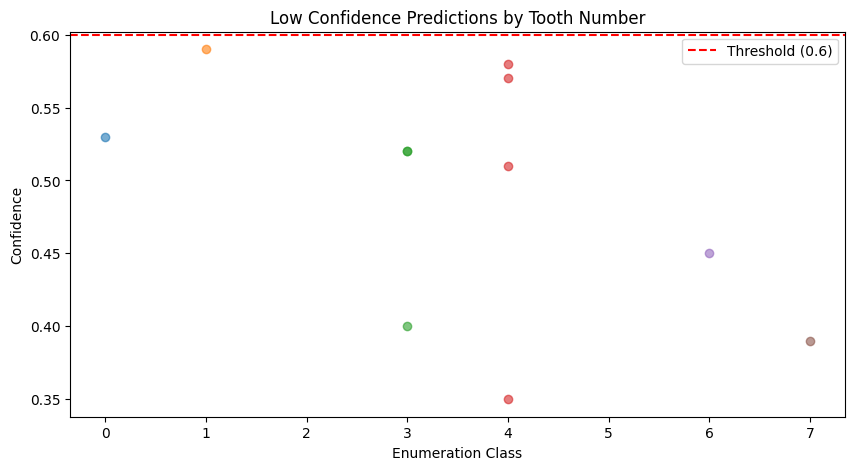


Total low confidence warnings: 11
            count    mean   min
enum_class                     
0               1  0.5300  0.53
1               1  0.5900  0.59
3               3  0.4800  0.40
4               4  0.5025  0.35
6               1  0.4500  0.45
7               1  0.3900  0.39

Average HIGH confidence (>= 0.6): 0.945
Average LOW confidence  (< 0.6): 0.462
Confidence Gap: 0.483  (std=0.098, n_low=43 -> large, model is inconsistent)


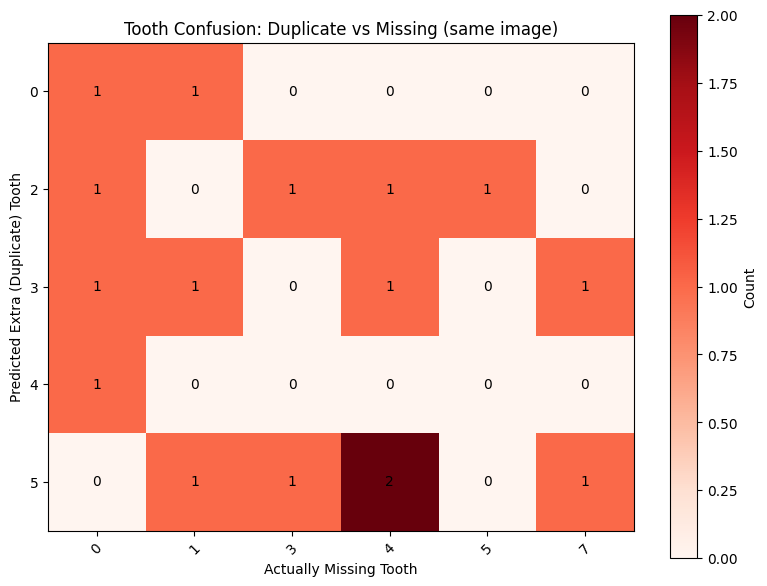


Top 10 problematic images (most warnings):
File_Name
train_66_LowerLeft.png      5
train_132_LowerRight.png    3
train_164_LowerLeft.png     3
train_212_UpperRight.png    3
train_308_UpperRight.png    3
train_621_UpperRight.png    3
train_63_LowerRight.png     3
train_131_LowerLeft.png     2
train_131_LowerRight.png    2
train_132_LowerLeft.png     2
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Enumeration Model Crop Analysis\test
File Name: train_110_LowerRight.png
Reason: tooth 6 box is 1.9x the median width, may span two teeth | tooth 5 box is 1.9x the median width, may span two teeth
File Name: train_131_LowerLeft.png
Reason: tooth 6 box is 2.1x the median width, may span two teeth | tooth 5 box is 1.7x the median width, may span two teeth
File Name: train_132_UpperLeft.png
Reason: tooth 6 box is 1.6x the median width, may span two teeth
File Name: train_132_UpperRight.png
Reason: tooth 6 box is 1.6x the median width, may span two teeth
File Name: train

In [14]:
s3_test_log_df = s3_test_results['test_set_results']['enumeration_detection_model_last']['log_df']
s3_test_worst_df = s3_test_results['test_set_results']['enumeration_detection_model_last']['worst_images_df']
analyze_full_teeth_predictions(s3_test_log_df,export_dir='../Runs/Stage 3/Enumeration Model Crop Analysis',split_name='test')
get_review_candidates(s3_test_log_df)